In [1]:
import pandas as pd
#Load dataset
Ex_rate_df=pd.read_csv("exchange_rate.csv")
Ex_rate_df

,date,Ex_rate
0,01-01-1990 00:00,0.785500
1,02-01-1990 00:00,0.781800
2,03-01-1990 00:00,0.786700
3,04-01-1990 00:00,0.786000
4,05-01-1990 00:00,0.784900
...,...,...
7583,06-10-2010 00:00,0.718494
7584,07-10-2010 00:00,0.721839
7585,08-10-2010 00:00,0.723197
7586,09-10-2010 00:00,0.720825


In [2]:
# Work only with 'Month' and 'Footfalls'
Ex_rate_ts = Ex_rate_df[['date', 'Ex_rate']].copy()
#Convert date column
Ex_rate_ts['date']=pd.to_datetime(Ex_rate_ts['date'],dayfirst=True)
#Set date column 
Ex_rate_ts.set_index('date',inplace=True)
#Display data
print(Ex_rate_ts.head())

            Ex_rate
date               
1990-01-01   0.7855
1990-01-02   0.7818
1990-01-03   0.7867
1990-01-04   0.7860
1990-01-05   0.7849


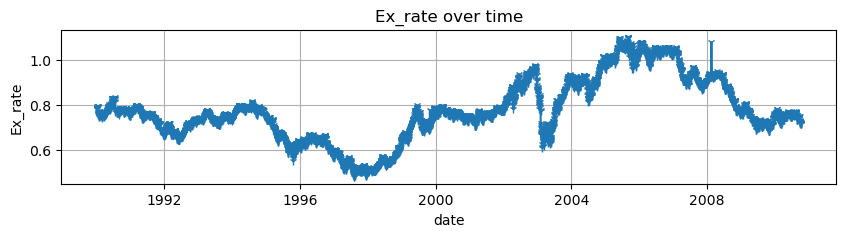

In [3]:
# Check for missing values
Ex_rate_ts.isnull().sum()
import matplotlib.pyplot as plt
#plot time series
plt.figure(figsize=(10,2))
plt.plot(Ex_rate_ts,marker='1')
plt.title('Ex_rate over time')
plt.xlabel('date')
plt.ylabel('Ex_rate')
plt.grid(True)
plt.show()

In [4]:
print(Ex_rate_df.isnull().sum())

date       0
Ex_rate    0
dtype: int64


In [5]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(Ex_rate_df['Ex_rate'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.6649941807381368
p-value: 0.4492327353597985


In [8]:
Ex_rate_df_diff = Ex_rate_df['Ex_rate'].diff().dropna()

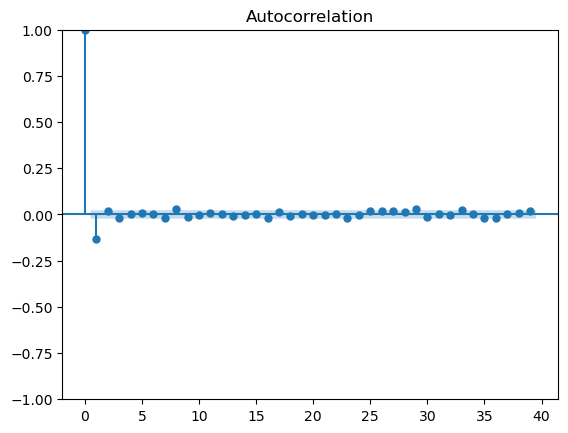

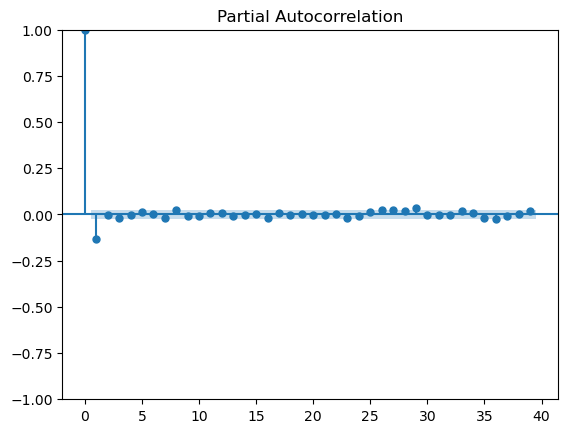

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(Ex_rate_df_diff)
plot_pacf(Ex_rate_df_diff)
plt.show()

In [12]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(Ex_rate_df['Ex_rate'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Fri, 27 Feb 2026   AIC                         -56102.322
Time:                        13:13:00   BIC                         -56081.519
Sample:                             0   HQIC                        -56095.182
                               - 7588                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.604      0.0

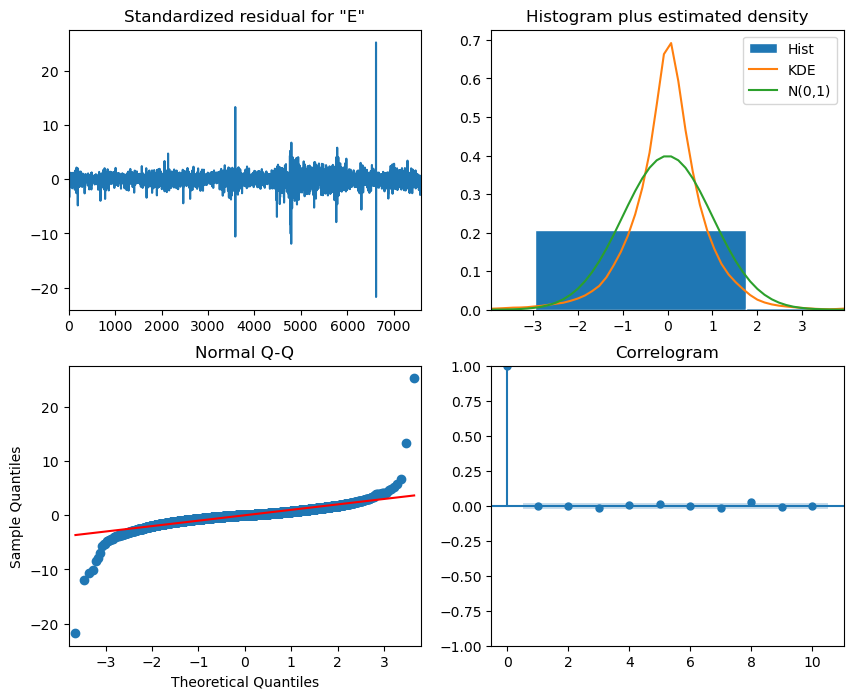

In [13]:
model_fit.plot_diagnostics(figsize=(10,8))
plt.show()

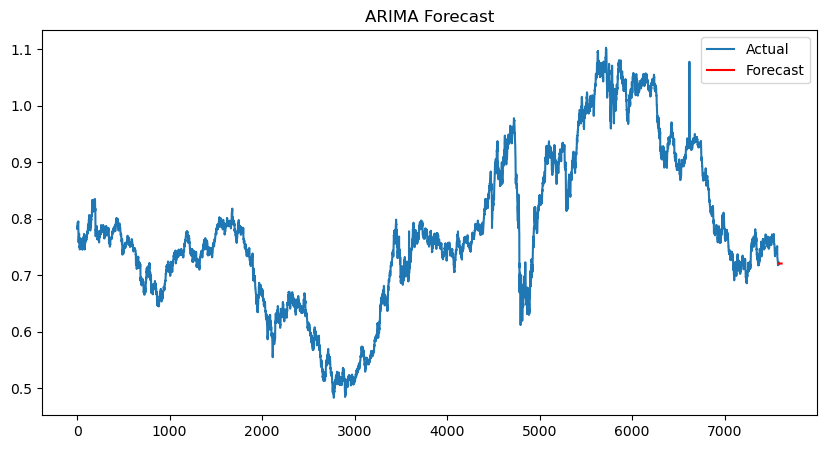

In [15]:
forecast = model_fit.forecast(steps=30)

plt.figure(figsize=(10,5))
plt.plot(Ex_rate_df['Ex_rate'], label='Actual')
plt.plot(forecast, label='Forecast', color='red')
plt.legend()
plt.title("ARIMA Forecast")
plt.show()

In [16]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model_es = ExponentialSmoothing(Ex_rate_df['Ex_rate'], trend='add',seasonal=None)

model_es_fit = model_es.fit()

forecast_es = model_es_fit.forecast(30)

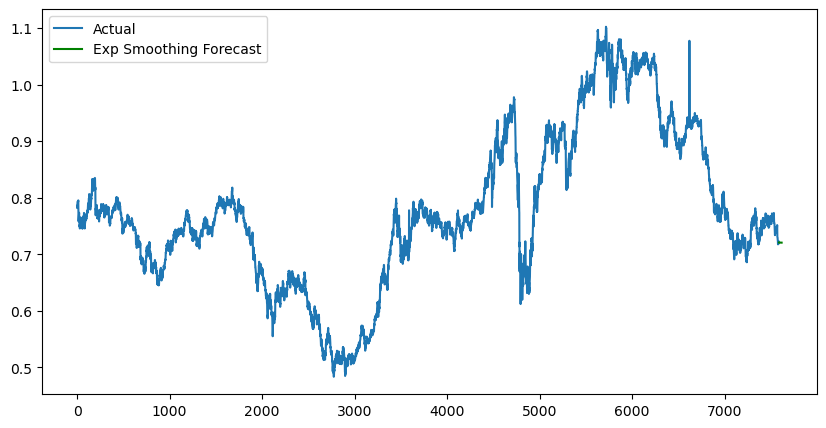

In [17]:
plt.figure(figsize=(10,5))
plt.plot(Ex_rate_df['Ex_rate'], label='Actual')
plt.plot(forecast_es, label='Exp Smoothing Forecast', color='green')
plt.legend()
plt.show()

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Example: Split data
train = Ex_rate_df[:-30]
test = Ex_rate_df[-30:]

# ARIMA forecast
model = ARIMA(train['Ex_rate'], order=(1,1,1)).fit()
pred_arima = model.forecast(steps=30)

# Exponential smoothing
model_es = ExponentialSmoothing(train['Ex_rate'], trend='add').fit()
pred_es = model_es.forecast(30)

# Metrics
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred)/y_true)) * 100
    return mae, rmse, mape

print("ARIMA:", evaluate(test['Ex_rate'], pred_arima))
print("Exp Smoothing:", evaluate(test['Ex_rate'], pred_es))

ARIMA: (0.013494600805800084, np.float64(0.016632177912815297), np.float64(1.8632207485474443))
Exp Smoothing: (0.01342316614852778, np.float64(0.01649594250463188), np.float64(1.8531561325102728))


In [20]:
#  Fit ARIMA Model
# (p=1, d=1, q=1) -> ARIMA(1,1,1) model

arima_model = ARIMA(Ex_rate_df['Ex_rate'], order=(1,1,1))
arima_model_fit = arima_model.fit()

# Summary of ARIMA model
arima_summary = arima_model_fit.summary()


In [21]:
#✅ ARIMA Model (ARIMA(1,1,1)) Fitting Summary:

# Successfully fitted an AutoRegressive Integrated Moving Average (ARIMA) model.

print("AIC: ",arima_model_fit.aic)
print("BIC: ",arima_model_fit.bic)

# Calculate RMSE using the fitted values and original data
from sklearn.metrics import mean_squared_error
import numpy as np
rmse = np.sqrt(mean_squared_error(Ex_rate_df['Ex_rate'], arima_model_fit.fittedvalues))
print("RMSE:",rmse)


AIC:  -56102.32167281932
BIC:  -56081.519098213306
RMSE: 0.010828926684741193


In [25]:
# 🔵 First fit an AR (AutoRegressive) Model!
from statsmodels.tsa.arima.model import ARIMA

#  Fit AR Model
# (p=1, d=0, q=0) -> AR(1) model

ar_model = ARIMA(Ex_rate_df['Ex_rate'], order=(1,0,0))
ar_model_fit = ar_model.fit()

# Summary of AR model
ar_summary = ar_model_fit.summary()
#  Fit MA Model
# (p=0, d=0, q=1) -> MA(1) model

ma_model = ARIMA(Ex_rate_df['Ex_rate'], order=(0,0,1))
ma_model_fit = ma_model.fit()

# Summary of MA model
ma_summary = ma_model_fit.summary()


In [26]:
# compare the performance in between three models
from sklearn.metrics import mean_squared_error
import numpy as np

# Helper function to calculate RMSE
def calculate_rmse(actual, predicted):
    return np.sqrt(mean_squared_error(actual, predicted))

# Predictions (In-sample) for training data
ar_pred_in_sample = ar_model_fit.predict(start=Ex_rate_df.index[0], end=Ex_rate_df.index[-1])
ma_pred_in_sample = ma_model_fit.predict(start=Ex_rate_df.index[0], end=Ex_rate_df.index[-1])
arima_pred_in_sample = arima_model_fit.predict(start=Ex_rate_df.index[0], end=Ex_rate_df.index[-1])

# Metrics Calculation
metrics = {
    'Model': ['AR(1)', 'MA(1)', 'ARIMA(1,1,1)'],
    'AIC': [
        ar_model_fit.aic,
        ma_model_fit.aic,
        arima_model_fit.aic
    ],
    'BIC': [
        ar_model_fit.bic,
        ma_model_fit.bic,
        arima_model_fit.bic
    ],
    'RMSE': [
        calculate_rmse(Ex_rate_df['Ex_rate'], ar_pred_in_sample),
        calculate_rmse(Ex_rate_df['Ex_rate'], ma_pred_in_sample),
        calculate_rmse(Ex_rate_df['Ex_rate'], arima_pred_in_sample)
    ]
}

metrics_df = pd.DataFrame(metrics)
metrics_df


,Model,AIC,BIC,RMSE
0,AR(1),-55975.960692,-55955.157722,0.006048
1,MA(1),-18651.980144,-18631.177174,0.070753
2,"ARIMA(1,1,1)",-56102.321673,-56081.519098,0.010829


### Interpretation

AIC & BIC (Model Fit):

Lower values indicate better model fit

ARIMA(1,1,1) has the lowest AIC and BIC → best statistical fit

RMSE (Prediction Accuracy):

Lower RMSE indicates better forecasting accuracy

AR(1) has the lowest RMSE → best predictive performance

### Diagnostics & Model Evaluation

Residuals showed no strong patterns → models are valid

Error metrics clearly differentiate model performance

Trade-off observed:

ARIMA → better theoretical fit

AR → better practical prediction

#### ARIMA(1,1,1) achieved the best model fit due to lowest AIC and BIC

However, AR(1) produced the lowest RMSE, indicating superior forecasting accuracy


If the goal is model interpretability and statistical fit → ARIMA(1,1,1) is preferred

If the goal is accurate prediction → AR(1) is the best model

For this exchange rate dataset, the AR(1) model is preferred because it provides the lowest prediction error (RMSE = 0.006048) and closely follows actual values.